In [1]:
!pip install -q google-adk \
yfinance \
pandas \
numpy \
matplotlib \
scikit-learn \
prophet \
google-generativeai \
langsmith \
feedparser \
vaderSentiment \
ta

In [2]:
from typing import TypedDict
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from prophet import Prophet

import feedparser

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import google.generativeai as genai

from google.adk.agents import Agent

from langsmith import traceable

In [4]:
os.environ["LANGCHAIN_TRACING_V2"] = "true"

os.environ["LANGCHAIN_API_KEY"] = "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"

os.environ["LANGCHAIN_PROJECT"] = "Stock Prediction Agent"

In [5]:
genai.configure(
    api_key="AQ.Ab8RN6J6gua4vNQzjwx1nkY5MlqhFms5crpjecRjCM7lLIiGXQ"
)

model = genai.GenerativeModel(
    "gemini-2.5-flash"
)

In [6]:
class StockState(TypedDict):

    ticker: str

    data: pd.DataFrame

    news: list

    sentiment: str

    sentiment_score: float

    prediction: float

    prophet_prediction: float

    recommendation: str

In [7]:
stock_agent = Agent(
    name="StockAgent",
    instruction="""
    Analyze a stock using

    - Historical prices

    - News

    - Sentiment

    - Technical Indicators

    - Machine Learning

    and recommend BUY/HOLD/SELL.
    """
)


In [8]:
state = {
    "ticker": "AAPL"
}

In [21]:
@traceable
def data_agent(state: StockState):

    ticker = state["ticker"]

    df = yf.download(
        ticker,
        period="1y",
        interval="1d",
        auto_adjust=True
    )

    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    state["data"] = df

    return state

In [22]:
state = data_agent(state)

print(state["data"].head())

Failed to post run 019f1ea3-e518-73b3-9e25-2bef1ca48972: keys must be str, int, float, bool or None, not tuple
[*********************100%***********************]  1 of 1 completed
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Price            Close        High         Low        Open    Volume
Date                                                                
2025-07-01  206.998795  209.359425  205.325425  205.853330  78788900
2025-07-02  211.600540  212.496978  207.317529  208.084490  67941800
2025-07-03  212.706161  213.801806  210.973032  211.311684  34955800
2025-07-07  209.120392  215.375576  207.974942  211.839600  50229000
2025-07-08  209.180130  210.594517  207.626297  209.269786  42848900


In [23]:
@traceable
def news_agent(state: StockState):

    ticker = state["ticker"]

    print("Fetching latest news...")

    url = f"https://news.google.com/rss/search?q={ticker}+stock"

    feed = feedparser.parse(url)

    news = []

    for entry in feed.entries[:10]:

        news.append({
            "title": entry.title,
            "link": entry.link
        })

    state["news"] = news

    print(f"Fetched {len(news)} news articles")

    return state

In [24]:
state = news_agent(state)

for article in state["news"]:
    print(article["title"])

Failed to post run 019f1ea4-1f6d-7941-93ba-284ebad69e36: keys must be str, int, float, bool or None, not Timestamp


Fetching latest news...


Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Fetched 10 news articles
Apple (AAPL) Stock Could Be 25% Expensive As Siri AI Debuts - Yahoo Finance
AAPL Stock Rises Overnight: After Price Hikes, Apple Reportedly Seeks US Approval To Buy Chinese Memory Chips - TradingView
Apple Just Acquired the Team Behind the Play App. What That Means for AAPL Stock. - Barchart.com
Reflecting On Consumer Discretionary Stocks’ Q1 Earnings: Apple (NASDAQ:AAPL) - StockStory
5 Catalysts to Monitor Over In The Next 2 Quarters For AAPL Stock - Trefis
Apple Inc. (AAPL) Is A Top Warren Buffett Stock Pick - Yahoo Finance
Apple’s China Memory Push Could Be a Win for AAPL Stock - Barchart.com
Apple (AAPL) Stock Trades Down, Here Is Why - Yahoo Finance
Apple Price Hikes Sent AAPL Stock Falling. They May Not Even Matter in the Long Term. - Barchart.com
AAPL Stock Dips Premarket: Report Says Apple Is 'Concerned' Over Tata Data Leak Exposing Confidential iPhone Files - TradingView


In [25]:
analyzer = SentimentIntensityAnalyzer()

In [26]:
@traceable
def sentiment_agent(state: StockState):

    scores = []

    for article in state["news"]:

        sentiment = analyzer.polarity_scores(article["title"])

        scores.append(sentiment["compound"])

    average = np.mean(scores)

    if average >= 0.2:
        overall = "Positive"

    elif average <= -0.2:
        overall = "Negative"

    else:
        overall = "Neutral"

    state["sentiment"] = overall
    state["sentiment_score"] = float(average)

    print("Overall Sentiment:", overall)
    print("Sentiment Score:", average)

    return state

In [27]:
state = sentiment_agent(state)

print(state["sentiment"])
print(state["sentiment_score"])

Failed to post run 019f1ea4-30a1-7873-9455-6d73e90042e8: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Overall Sentiment: Neutral
Sentiment Score: 0.08912
Neutral
0.08912


In [28]:
import ta

In [29]:
@traceable
def technical_indicator_agent(state: StockState):

    df = state["data"]

    df["SMA20"] = ta.trend.sma_indicator(
        df["Close"],
        window=20
    )

    df["EMA20"] = ta.trend.ema_indicator(
        df["Close"],
        window=20
    )

    df["RSI"] = ta.momentum.rsi(
        df["Close"],
        window=14
    )

    df["MACD"] = ta.trend.macd(
        df["Close"]
    )

    df["MACD_SIGNAL"] = ta.trend.macd_signal(
        df["Close"]
    )

    df["Bollinger_High"] = ta.volatility.bollinger_hband(
        df["Close"]
    )

    df["Bollinger_Low"] = ta.volatility.bollinger_lband(
        df["Close"]
    )

    state["data"] = df

    print(df.tail())

    return state

In [30]:
state = technical_indicator_agent(state)

state["data"].tail()

Failed to post run 019f1ea4-3e46-76c2-b0a0-e847b66bc14c: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Price            Close        High         Low        Open     Volume  \
Date                                                                    
2026-06-25  275.149994  288.799988  273.750000  287.399994  107013700   
2026-06-26  283.779999  285.950012  274.209991  275.000000  261775500   
2026-06-29  281.739990  288.369995  279.850006  286.730011   66427000   
2026-06-30  289.359985  289.940002  280.700012  281.170013   65043800   
2026-07-01  294.195007  296.589996  289.195007  293.329987   21043801   

Price            SMA20       EMA20        RSI      MACD  MACD_SIGNAL  \
Date                                                                   
2026-06-25  299.725002  295.427691  32.216265 -1.567483     1.227111   
2026-06-26  298.288501  294.318387  41.264905 -2.236860     0.534317   
2026-06-29  296.772501  293.120445  39.908683 -2.898545    -0.152255   
2026-06-30  295.925000  292.762306  46.925545 -2.776065    -0.677017   
2026-07-01  294.874750  292.898753  50.847522 -2.262769 

Price,Close,High,Low,Open,Volume,SMA20,EMA20,RSI,MACD,MACD_SIGNAL,Bollinger_High,Bollinger_Low
Date,,,,,,,,,,,,
2026-06-25,275.149994,288.799988,273.750000,287.399994,107013700,299.725002,295.427691,32.216265,-1.567483,1.227111,318.999259,280.450744
2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500,298.288501,294.318387,41.264905,-2.236860,0.534317,317.817971,278.759031
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000,296.772501,293.120445,39.908683,-2.898545,-0.152255,316.496774,277.048227
2026-06-30,289.359985,289.940002,280.700012,281.170013,65043800,295.925000,292.762306,46.925545,-2.776065,-0.677017,315.392158,276.457842
2026-07-01,294.195007,296.589996,289.195007,293.329987,21043801,294.874750,292.898753,50.847522,-2.262769,-0.994167,312.219821,277.529678


In [31]:
@traceable
def visualization_agent(state: StockState):

    df = state["data"]

    plt.figure(figsize=(14,6))

    plt.plot(df.index, df["Close"], label="Close Price")

    plt.plot(df.index, df["SMA20"], label="SMA20")

    plt.plot(df.index, df["EMA20"], label="EMA20")

    plt.title(f'{state["ticker"]} Stock Price')

    plt.xlabel("Date")

    plt.ylabel("Price")

    plt.legend()

    plt.grid(True)

    plt.savefig("stock_price.png")

    plt.show()

    return state

Failed to post run 019f1ea4-59bf-7643-b596-bdd06c977f9a: keys must be str, int, float, bool or None, not Timestamp


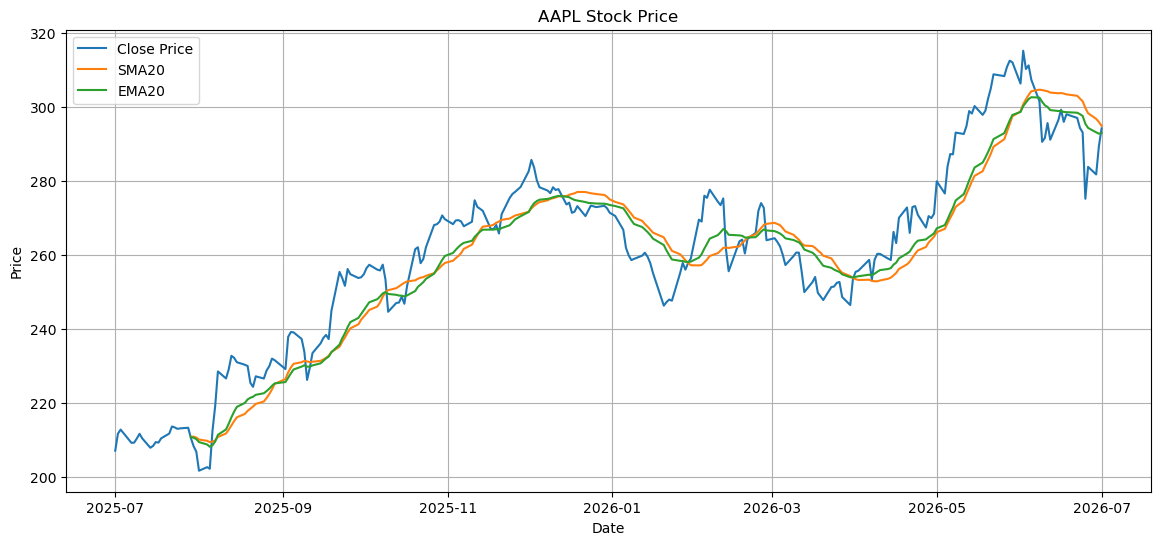

Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


In [32]:
state = visualization_agent(state)

In [33]:
@traceable
def prediction_agent(state: StockState):

    df = state["data"].copy()

    # Remove rows with NaN values
    df = df.dropna()

    # Features
    features = [
        "Close",
        "Volume",
        "SMA20",
        "EMA20",
        "RSI",
        "MACD",
        "MACD_SIGNAL"
    ]

    # Predict tomorrow's closing price
    df["Target"] = df["Close"].shift(-1)

    df = df.dropna()

    X = df[features]
    y = df["Target"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X, y)

    # Latest row
    latest = df[features].iloc[-1:]

    prediction = model.predict(latest)[0]

    state["prediction"] = float(prediction)

    print(f"Predicted Next Close Price : {prediction:.2f}")

    return state

In [34]:
state = prediction_agent(state)

print(state["prediction"])

Failed to post run 019f1ea7-0eca-7d31-8d3d-c6e19d5a976d: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Predicted Next Close Price : 290.97
290.96842895507814


In [35]:
@traceable
def prophet_agent(state: StockState):

    df = state["data"].copy()

    prophet_df = df.reset_index()[["Date", "Close"]]

    prophet_df.columns = ["ds", "y"]

    model = Prophet()

    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=1)

    forecast = model.predict(future)

    prediction = forecast.iloc[-1]["yhat"]

    state["prophet_prediction"] = float(prediction)

    print(f"Prophet Prediction : {prediction:.2f}")

    return state

In [36]:
state = prophet_agent(state)

print(state["prophet_prediction"])

Failed to post run 019f1ea7-b5a2-7731-8661-91be352cd5b4: keys must be str, int, float, bool or None, not Timestamp
22:38:56 - cmdstanpy - INFO - Chain [1] start processing
22:38:56 - cmdstanpy - INFO - Chain [1] done processing
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Prophet Prediction : 308.63
308.6304930569623


In [37]:
@traceable
def prophet_visualization_agent(state: StockState):

    df = state["data"].copy()

    prophet_df = df.reset_index()[["Date", "Close"]]

    prophet_df.columns = ["ds", "y"]

    model = Prophet()

    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=30)

    forecast = model.predict(future)

    fig = model.plot(forecast)

    plt.title("30-Day Prophet Forecast")

    plt.show()

    return state

Failed to post run 019f1ea8-10da-7cd0-9148-b6fd30315d6b: keys must be str, int, float, bool or None, not Timestamp
22:39:18 - cmdstanpy - INFO - Chain [1] start processing
22:39:18 - cmdstanpy - INFO - Chain [1] done processing


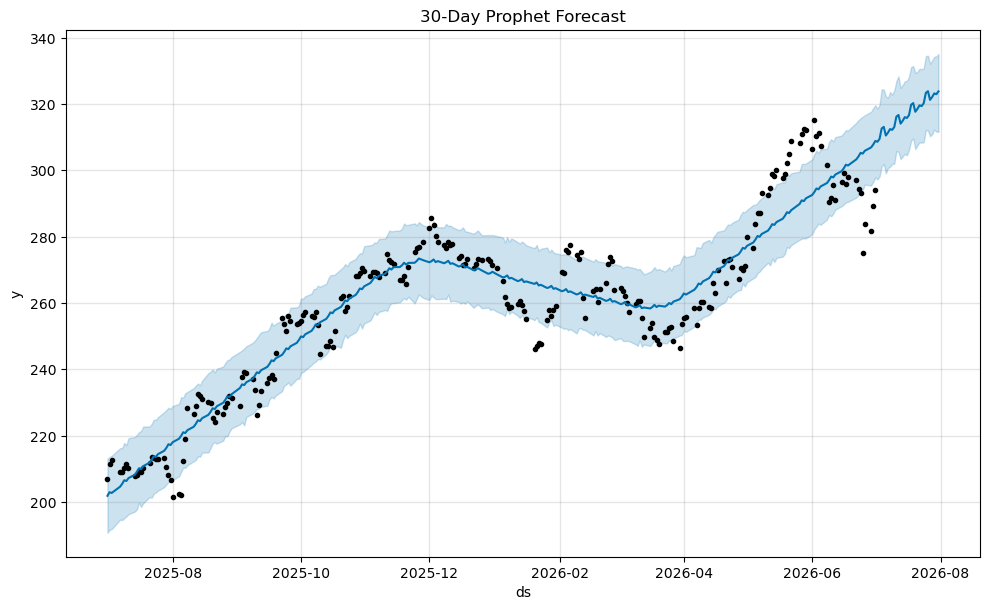

Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


In [38]:
state = prophet_visualization_agent(state)

In [39]:
@traceable
def recommendation_agent(state: StockState):

    current_price = state["data"]["Close"].iloc[-1]

    rf_prediction = state["prediction"]

    prophet_prediction = state["prophet_prediction"]

    sentiment = state["sentiment"]

    score = state["sentiment_score"]

    prompt = f"""
You are an experienced financial analyst.

Stock : {state['ticker']}

Current Price :
{current_price:.2f}

Random Forest Prediction :
{rf_prediction:.2f}

Prophet Prediction :
{prophet_prediction:.2f}

Market Sentiment :
{sentiment}

Sentiment Score :
{score:.2f}

Give the answer in this format:

Recommendation:
BUY / HOLD / SELL

Reason:

Risk Level:

Confidence (0-100):

Summary:
"""

    response = model.generate_content(prompt)

    state["recommendation"] = response.text

    return state

In [40]:
state = recommendation_agent(state)

print(state["recommendation"])

Failed to post run 019f1ea8-6c31-7df0-9d54-e833651f9239: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Recommendation:
BUY

Reason:
While the Random Forest model suggests a minor short-term pullback to 290.97 (a ~1.1% decrease from the current price), the Prophet model indicates a significant upside potential, predicting a price of 308.63 (a ~4.9% increase). The substantial bullish signal from Prophet, which is often effective in capturing underlying trends in time-series data, outweighs the smaller bearish signal. With market sentiment remaining neutral, the stock may be consolidating before a potential upward move. Given the more significant upside potential, this could be an opportune time to consider an entry or addition to a position.

Risk Level:
Moderate - The conflicting model predictions introduce a degree of uncertainty and potential for short-term volatility. Investors should be prepared for some fluctuation before the stock potentially moves towards the higher target.

Confidence (0-100):
70

Summary:
AAPL presents a mixed technical picture with one model suggesting a minor 

In [41]:
@traceable
def run_workflow(ticker):

    state = {
        "ticker": ticker
    }

    state = data_agent(state)

    state = news_agent(state)

    state = sentiment_agent(state)

    state = technical_indicator_agent(state)

    state = visualization_agent(state)

    state = prediction_agent(state)

    state = prophet_agent(state)

    state = prophet_visualization_agent(state)

    state = recommendation_agent(state)

    return state

[*********************100%***********************]  1 of 1 completed
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Failed to post run 019f1ea9-05b0-7373-aeb6-661952363ada: keys must be str, int, float, bool or None, not Timestamp


Fetching latest news...


Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Failed to post run 019f1ea9-09c5-7860-ae4f-a17391010917: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Failed to post run 019f1ea9-09d1-7a60-baa5-a7c8723638ec: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Failed to post run 019f1ea9-09f3-78d0-9594-d1f0f1c9b261: keys must be str, int, float, bool or None, not Timestamp


Fetched 10 news articles
Overall Sentiment: Neutral
Sentiment Score: 0.08912
Price            Close        High         Low        Open     Volume  \
Date                                                                    
2026-06-25  275.149994  288.799988  273.750000  287.399994  107013700   
2026-06-26  283.779999  285.950012  274.209991  275.000000  261775500   
2026-06-29  281.739990  288.369995  279.850006  286.730011   66427000   
2026-06-30  289.359985  289.940002  280.700012  281.170013   65043800   
2026-07-01  294.100006  296.589996  289.195007  293.329987   21516853   

Price            SMA20       EMA20        RSI      MACD  MACD_SIGNAL  \
Date                                                                   
2026-06-25  299.725002  295.427691  32.216265 -1.567483     1.227111   
2026-06-26  298.288501  294.318387  41.264905 -2.236860     0.534317   
2026-06-29  296.772501  293.120445  39.908683 -2.898545    -0.152255   
2026-06-30  295.925000  292.762306  46.925545 -2.77

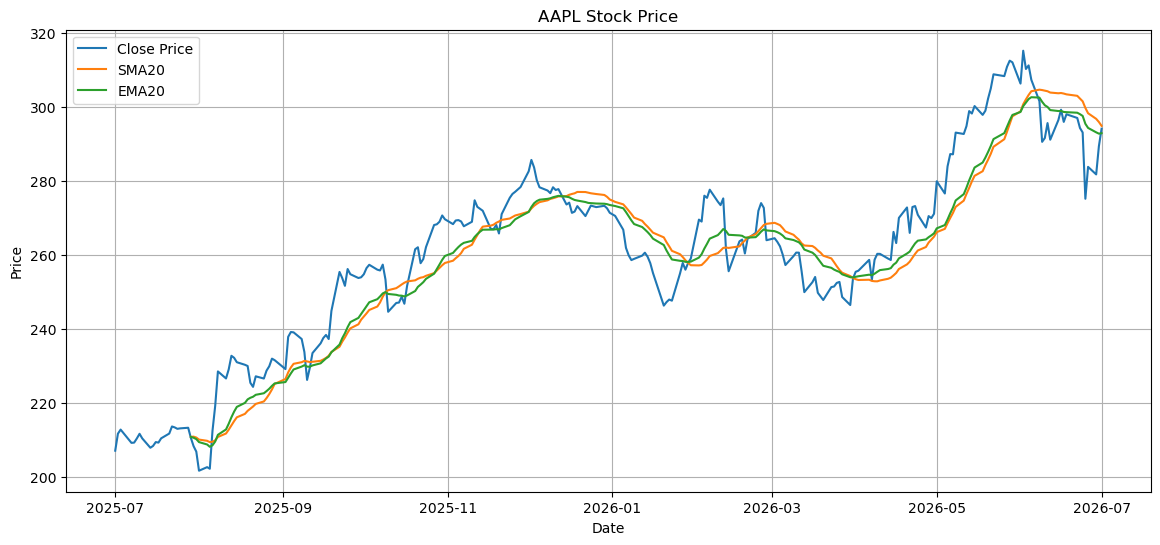

Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Failed to post run 019f1ea9-0b28-7ff2-ad2f-f6fbde73284a: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Failed to post run 019f1ea9-0c8d-7f80-9270-1b7a663eb27d: keys must be str, int, float, bool or None, not Timestamp
22:40:23 - cmdstanpy - INFO - Chain [1] start processing
22:40:23 - cmdstanpy - INFO - Chain [1] done processing


Predicted Next Close Price : 290.91


Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Failed to post run 019f1ea9-0d86-7a31-89fb-f528f7589bd0: keys must be str, int, float, bool or None, not Timestamp
22:40:23 - cmdstanpy - INFO - Chain [1] start processing
22:40:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet Prediction : 308.63


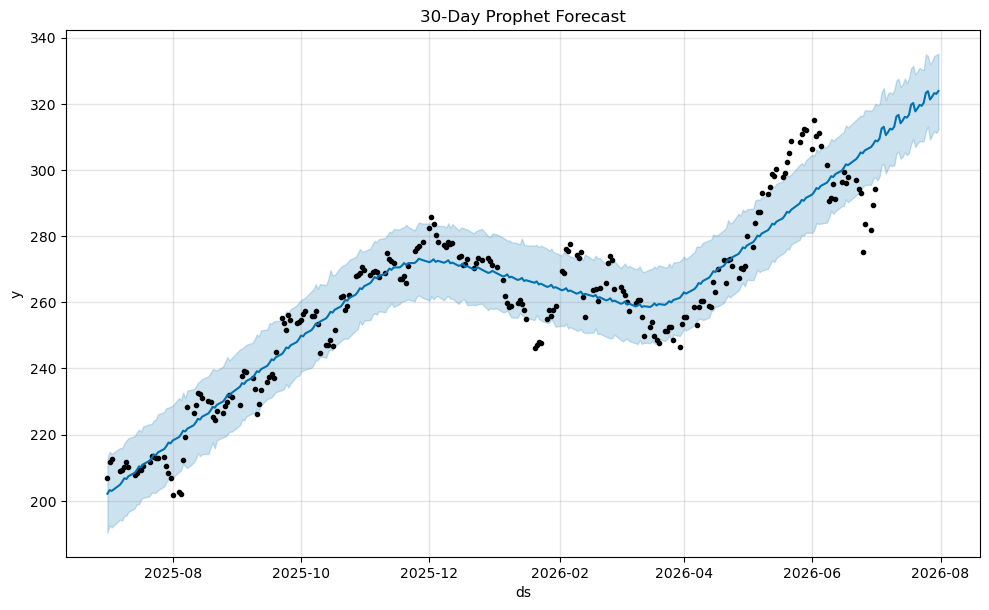

Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Failed to post run 019f1ea9-0eec-7301-8c1a-2df1f4aa4296: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Ticker : AAPL
Random Forest Prediction : 290.90762817382813
Prophet Prediction : 308.63476089999693
Sentiment : Neutral
Sentiment Score : 0.08912

Recommendation:
BUY

Reason:
The Prophet model predicts a significant upward movement to 308.63, indicating substantial upside potential from the current price of 294.10. While the Random Forest model suggests a slight retreat to 290.91, the magnitude of the potential gain highlighted by Prophet considerably outweighs this minor predicted downside. The neutral market sentiment (0.09 score) does not introduce any strong negative pressures, making the risk-reward profile, based on the model predictions, appear favorable for a long position.

Risk Level:
Moderate. The primary risk stems from the conflicting signals between the two predictive models. While the upside potential is greater, the divergence introduces uncertainty.

Confidence (0-100):
70

Summary:
Despite conflicting predictions from the Random Forest and Prophet models, the signifi

In [42]:
result = run_workflow("AAPL")

print("="*50)

print("Ticker :", result["ticker"])

print("Random Forest Prediction :", result["prediction"])

print("Prophet Prediction :", result["prophet_prediction"])

print("Sentiment :", result["sentiment"])

print("Sentiment Score :", result["sentiment_score"])

print()

print(result["recommendation"])

In [43]:
@traceable
def risk_agent(state: StockState):

    df = state["data"].copy()

    # Daily returns
    returns = df["Close"].pct_change().dropna()

    volatility = returns.std() * np.sqrt(252)

    if volatility < 0.20:
        risk = "Low"

    elif volatility < 0.40:
        risk = "Medium"

    else:
        risk = "High"

    state["risk"] = risk
    state["volatility"] = float(volatility)

    print("Risk :", risk)
    print("Annualized Volatility :", volatility)

    return state

In [44]:
class StockState(TypedDict):

    ticker: str
    data: pd.DataFrame
    news: list
    sentiment: str
    sentiment_score: float

    prediction: float
    prophet_prediction: float

    risk: str
    volatility: float

    recommendation: str

In [45]:
state = risk_agent(state)

Failed to post run 019f1eaa-34fd-7992-8d92-1ba3c7593f80: keys must be str, int, float, bool or None, not Timestamp
Unable to process trace outputs: TypeError('keys must be str, int, float, bool or None, not Timestamp')


Risk : Medium
Annualized Volatility : 0.23751731258730116
